In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [63]:
df = pd.read_csv('data/reviewslabeled.csv')
# KEEP ONLY LEGITIMATE REVIEWS
df = df[df['Authenticity'] == 'Legitimate']
# remove columns that have unnamed in the name
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# remove white space from column names
df.columns = df.columns.str.strip()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 0 to 1079
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   source          1014 non-null   object
 1   size            1014 non-null   object
 2   comment         1014 non-null   object
 3   original        1014 non-null   object
 4   Satisfaction    1014 non-null   int64 
 5   Authenticity    1014 non-null   object
 6   Type            1014 non-null   object
 7   needs_response  1014 non-null   object
 8   Category        1014 non-null   object
 9   Impact          1014 non-null   object
 10  Emotion         1014 non-null   object
dtypes: int64(1), object(10)
memory usage: 95.1+ KB


In [66]:
# find duplicate rows in the column comment
duplicates = df[df.duplicated('original')]
print(duplicates.shape)

(12, 11)


In [67]:
duplicates.head(22)

,source,size,comment,original,Satisfaction,Authenticity,Type,needs_response,Category,Impact,Emotion
136,Yalidine Maabouda Setif,short,I didn't really like the service,J'ai pas trop aimé le service,1,Legitimate,Complaint,Yes,"Customer Service, Product Quality / Food Quality",Low Impact,Disappointment
224,Yalidine Hidhab Setif,short,Impeccable service,Service impeccable,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
508,Attraction Park Setif,short,Wonderful garden,Wonderful garden,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
517,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
518,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
519,Attraction Park Setif,short,Very beautiful,Very beautiful,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
765,EMS SETIF,short,Impeccable service,Service impeccable,5,Legitimate,Praise,No,Customer Service,No issue,Gratitude
823,DHL Setif,short,Fast service,Service rapide,5,Legitimate,Praise,No,Customer Service,No issue,Satisfaction
882,La Citadelle,short,Disastrous services,خدمات كارثية,1,Legitimate,Complaint,Yes,Customer Service,High,Anger
1001,La Citadelle,short,magnificence,روعة,5,Legitimate,Praise,No,Customer Service,No issue,Excitement


In [68]:
df = df.drop_duplicates('original')
df.shape

(1002, 11)

Text(0.5, 1.0, 'Distribution of Review Types')

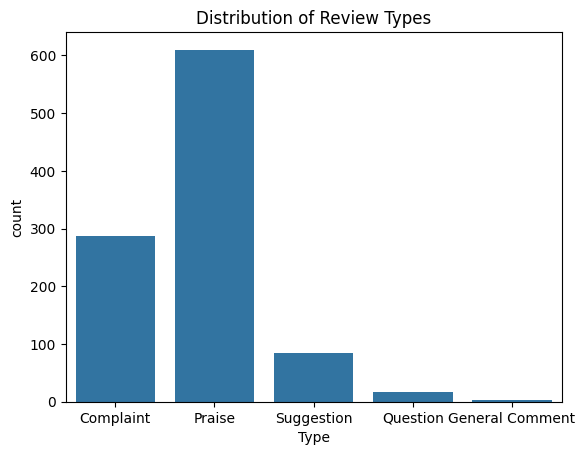

In [69]:
sns.countplot(x='Type', data=df)
plt.title('Distribution of Review Types')

In [57]:
df.columns

Index(['source', 'size', 'comment', 'original', 'Satisfaction ',
       'Authenticity', 'Type', 'needs_response', 'Category ', 'Impact',
       ' Emotion'],
      dtype='object')

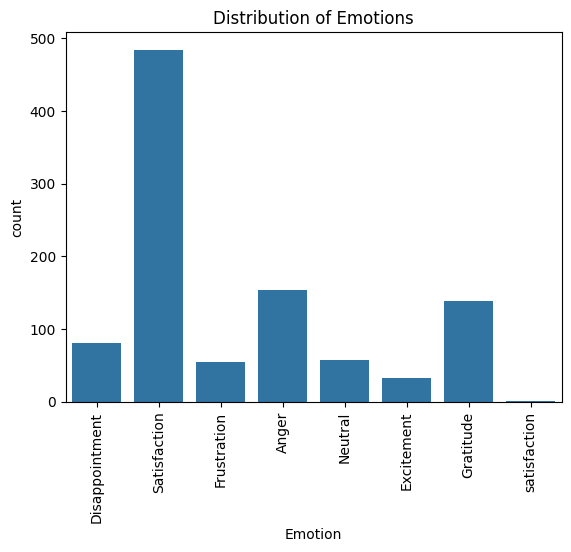

In [70]:
sns.countplot(x='Emotion', data=df)
plt.title('Distribution of Emotions')
plt.xticks(rotation=90)
plt.show()

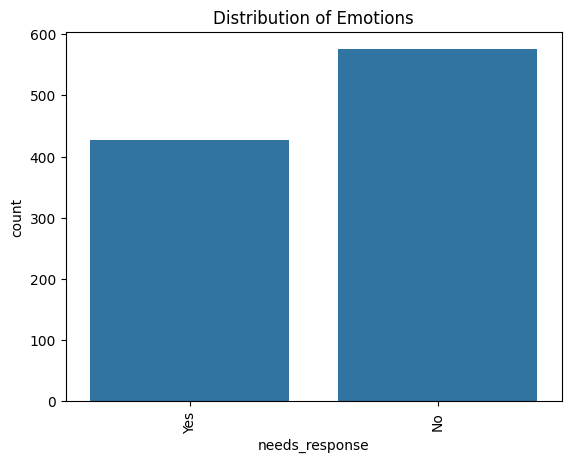

In [71]:
sns.countplot(x='needs_response', data=df)
plt.title('Distribution of Emotions')
plt.xticks(rotation=90)
plt.show()

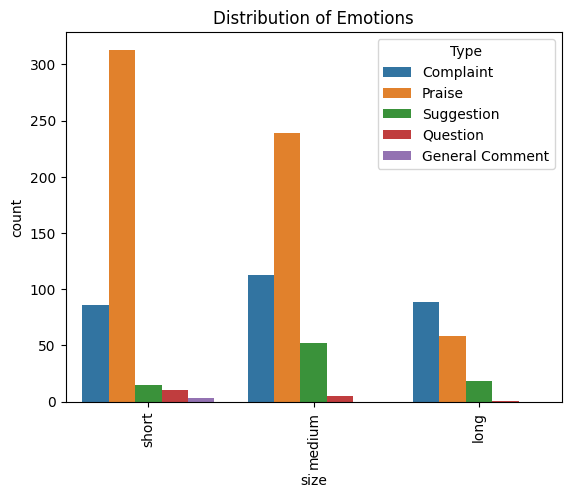

In [73]:
sns.countplot(x='size', data=df, hue='Type')
plt.title('Distribution of Emotions')
plt.xticks(rotation=90)
plt.show()

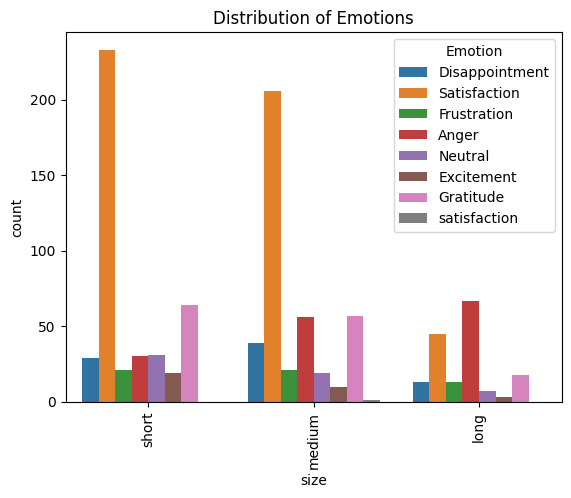

In [74]:
sns.countplot(x='size', data=df, hue='Emotion')
plt.title('Distribution of Emotions')
plt.xticks(rotation=90)
plt.show()

In [75]:
%pip install langdetect langid textblob cld2 cld3 polyglot fasttext


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 KB 4.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.9 MB/s eta 0:00:00ta 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 KB 13.3 MB/s eta 0:00:00a 0:00:01
ERROR: Could not find a version that satisfies the requirement cld2 (from versions: none)
ERROR: No matching distribution found for cld2
Note: you may need to restart the kernel to use updated packages.
